# STAT201 · 2-hafta · Kompyuter laboratoriyasi (Python)

### Ehtimollik asoslari: sanash, qoʻshish qoidasi, bogʻliqsizlik va simulyatsiya

**Toshkent Xalqaro Universiteti · Iqtisodiyot fakulteti · 2025/2026**

---

**Maqsad.** Maʼruzada aksioma va formula sifatida koʻrgan ehtimollikni
haqiqiy maʼlumot ustida **sanab** qayta qurish, qoidalarni son bilan
tekshirish va nazariy javobni **simulyatsiya** bilan mustaqil tasdiqlash.

**Asosiy gʻoya.** Agar maʼlumot toʻplamining har bir qatori teng
imkoniyatli natija deb qaralsa, u holda ehtimollik — bu shunchaki **ulush**:

$$\Pr(A) \;=\; \frac{n(A)}{n}.$$

Shu sababli bugungi barcha ehtimolliklarni siz `.sum()` va `.mean()`
yordamida, formulaga ishonmasdan, **oʻzingiz sanab** olasiz. Formula esa
sanoq natijasini *tekshirish* uchun ishlatiladi — teskarisi emas.

**Ish zanjiri.** Har bir topshiriqda quyidagi ketma-ketlikni yozma
ravishda bajarasiz:

> **statistik tushuncha → maʼlumot → kod → natija → talqin → qaror**

Faqat kod yozib, natijani izohsiz qoldirish — topshiriq bajarilmagan
hisoblanadi. Baholashning yarmidan koʻpi aynan *talqin* va *qaror*
bosqichlariga beriladi.

**Vaqt va ball taqsimoti (120 daqiqa, 115 ball + 5 bonus).**

| # | Mazmun | Daqiqa | Blum | Ball |
|---|---|---|---|---|
| 0 | Muhitni sozlash | 5 | — | — |
| 1 | Elementar hodisalar fazosini qurish, kontingensiya jadvali | 15 | Tushunish | 15 |
| 2 | Qoʻshish qoidasini sanab tekshirish | 20 | Qoʻllash | 20 |
| 3 | Bogʻliqsizlik: bogʻliq va deyarli bogʻliqsiz juftlik | 20 | Tahlil | 20 |
| 4 | Shartli ehtimollik ikki yoʻnalishda | 15 | Tahlil | 15 |
| 5 | Monte-Karlo va katta sonlar qonuni | 25 | Baholash | 25 |
| 6 | Tugʻilgan kun masalasi: simulyatsiya vs aniq formula | 20 | Baholash | 20 |
| 7 | Ixtiyoriy: hosildorlik maʼlumotidagi hodisalar | uyda | Yaratish | +5 |

**Ogohlantirish.** 3-haftada oʻrganiladigan **toʻliq ehtimollik
formulasi** va **Bayes teoremasi** bu laboratoriyada qoʻllanmaydi. Bugun
faqat sanoq, qoʻshish qoidasi, shartli ehtimollik taʼrifi, koʻpaytirish
qoidasi va bogʻliqsizlik bilan ishlaymiz.

**Bu daftar R varianti (`W02-lab-R.Rmd`) bilan bir xil sonlarni beradi.**
5- va 6-topshiriqlardagi simulyatsiya uchun umumiy generator (MINSTD)
qoʻllanadi — sababi 5-topshiriqda tushuntirilgan.

## 0-bosqich. Muhitni sozlash

In [1]:
# --- Kerakli kutubxonalar --------------------------------------------
# pandas     — jadval koʻrinishidagi maʼlumot (DataFrame)
# numpy      — sonli massivlar va vektor amallari
# matplotlib — grafiklar
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print("pandas", pd.__version__, "| numpy", np.__version__,
      "| matplotlib", matplotlib.__version__)

# Jadvallarni oʻqishga qulay qilib koʻrsatamiz.
pd.set_option("display.width", 110)
pd.set_option("display.max_columns", 20)

%matplotlib inline

pandas 3.0.2 | numpy 2.4.4 | matplotlib 3.10.9


In [2]:
# --- Grafiklarda oʻzbekcha «ʻ» belgisi (U+02BB) ----------------------
# matplotlib matnni tanlangan shrift bilan chizadi. Agar shriftda U+02BB
# glifi boʻlmasa, uning oʻrnida QUTICHA (□) chiqadi va «Glyph 699 ...
# missing from font(s)» ogohlantirishi beriladi.
# Shriftni TASODIFGA QOLDIRMANG — oshkora belgilang.
plt.rcParams["font.family"] = "DejaVu Sans"   # U+02BB bu shriftda BOR

# QOIDA: baribir grafik yorliqlarida faqat ASCII harflardan foydalanamiz
# ("Ozbekiston", "bogliqsiz" va h.k.) — shunda har qanday muhitda,
# jumladan R ning standart pdf() qurilmasida ham, matn buzilmaydi.

# --- Okabe-Ito palitrasi (rang koʻrmaslikka moslashgan) ---------------
oiBlue, oiOrange, oiGreen = "#0072B2", "#E69F00", "#009E73"
oiPink, oiVerm, oiSky     = "#CC79A7", "#D55E00", "#56B4E9"

plt.rcParams.update({
    "figure.figsize": (7.0, 4.2),
    "figure.dpi": 110,
    "font.size": 10,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#E3E8EC",
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
print("shrift:", plt.rcParams["font.family"])

shrift: ['DejaVu Sans']


---
## 1-topshiriq. Elementar hodisalar fazosini qurish

**Qiyinlik: 2 (Konseptual) · Blum: Tushunish · 15 ball · 15 daqiqa**

### Statistik tushuncha

**Tasodifiy tajriba** *(random experiment)* — natijasi oldindan aniq
maʼlum boʻlmagan jarayon. **Elementar hodisalar fazosi** *(sample space)*
$S$ — barcha mumkin boʻlgan natijalar toʻplami. **Hodisa** *(event)* —
$S$ ning qism toʻplami.

Bugungi tajriba: *maʼlumot toʻplamidan tasodifiy bitta filmni tanlash*.
Har bir film — bitta elementar natija. Agar tanlov teng imkoniyatli
boʻlsa (biz shunday deb faraz qilamiz), u holda

$$\Pr(A) = \frac{n(A)}{n},\qquad n = |S|.$$

**Fazoni aniqlash — pedantlik emas, majburiyat.** Reytingi
koʻrsatilmagan filmlar reyting hodisalari uchun `NaN` beradi. Ularni
fazoda qoldirsak, barcha ehtimolliklar biroz siljiydi. Shu sababli
**fazoni oshkora toraytiramiz** va buni hisobotda yozamiz.

### Maʼlumot

`data/kinolar-byudjet.csv` — 2000–2018-yillardagi yirik byudjetli
filmlar (manba: *The Numbers* / Kaggle ochiq toʻplami). Ustunlar: `nomi`,
`yil`, `janr`, `reyting` (MPAA), `distribyutor`, `byudjet`,
`ichki_daromad`, `jahon_daromadi`.

In [3]:
# pd.read_csv() — vergul ajratgichli faylni DataFrame ga oʻqiydi.
# encoding="utf-8" — MAJBURIY: fayl UTF-8 da yozilgan; boshqa kodlashda
# oʻzbekcha belgilar buziladi (7-topshiriqda buni koʻrasiz).
kino = pd.read_csv("data/kinolar-byudjet.csv", encoding="utf-8")

print(kino.shape)        # (qatorlar, ustunlar)

(2467, 8)


In [4]:
# .info() — R dagi str() ning ekvivalenti: ustun nomlari, turlari va
# boʻsh boʻlmagan qiymatlar soni.
kino.info()

<class 'pandas.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   nomi            2467 non-null   str    
 1   yil             2467 non-null   int64  
 2   janr            2467 non-null   str    
 3   reyting         2458 non-null   str    
 4   distribyutor    2444 non-null   str    
 5   byudjet         2467 non-null   float64
 6   ichki_daromad   2467 non-null   float64
 7   jahon_daromadi  2467 non-null   float64
dtypes: float64(3), int64(1), str(4)
memory usage: 154.3 KB


In [5]:
# .unique() — kategorik oʻzgaruvchining darajalari (levels)
print(kino["janr"].unique())
print(kino["reyting"].unique())

<StringArray>
['Comedy', 'Adventure', 'Action', 'Drama', 'Horror']
Length: 5, dtype: str
<StringArray>
['PG', 'PG-13', 'G', 'R', nan]
Length: 5, dtype: str


In [6]:
# --- Yetishmayotgan qiymatlarni TEKSHIRISH (taxmin qilmang!) ---------
# .isna() — har bir katak uchun True/False; .sum() ularni sanaydi.
print(kino.isna().sum())

nomi               0
yil                0
janr               0
reyting            9
distribyutor      23
byudjet            0
ichki_daromad      0
jahon_daromadi     0
dtype: int64


In [7]:
# --- Ishchi fazoni qurish --------------------------------------------
# .dropna(subset=[...]) — koʻrsatilgan ustunda NaN boʻlgan qatorlarni
# olib tashlaydi. Bu QAROR: uni hisobotda oshkora yozish shart.
# .copy() — keyingi amallarda SettingWithCopyWarning chiqmasligi uchun.
kino_t = kino.dropna(subset=["reyting"]).copy()

n_xom = len(kino)        # xom maʼlumotdagi qatorlar
n     = len(kino_t)      # ISHCHI FAZO hajmi |S|
n_yoq = n_xom - n        # chiqarib tashlangan kuzatuvlar

print("xom satrlar          :", n_xom)
print("reytingi yoʻq        :", n_yoq)
print("ISHCHI FAZO |S| = n  :", n)
print("ulushi               : {:.2f}%".format(100 * n_yoq / n_xom))

xom satrlar          : 2467
reytingi yoʻq        : 9
ISHCHI FAZO |S| = n  : 2458
ulushi               : 0.36%


In [8]:
# --- Kontingensiya jadvali -------------------------------------------
# pd.crosstab(x, y) — ikki kategorik oʻzgaruvchi kesishmasidagi
# CHASTOTALAR. margins=True — qator va ustun yigʻindilarini qoʻshadi.
# Marginal yigʻindilar — «marginal ehtimollik» atamasining manbai:
# ular jadvalning CHETIDA (margin) turadi.
jadval = pd.crosstab(kino_t["janr"], kino_t["reyting"],
                     margins=True, margins_name="Jami")
jadval = jadval[["G", "PG", "PG-13", "R", "Jami"]]
print(jadval.to_string())

reyting     G   PG  PG-13     R  Jami
janr                                 
Action      0    6    178   174   358
Adventure  41  246     62    14   363
Comedy      3   39    266   292   600
Drama       5  106    339   479   929
Horror      0    3     51   154   208
Jami       49  400    896  1113  2458


In [9]:
# Nazorat: jadvalning umumiy yigʻindisi n ga teng boʻlishi SHART.
# Agar teng boʻlmasa — fazo notoʻgʻri qurilgan.
print("jadval yigʻindisi:", int(jadval.loc["Jami", "Jami"]),
      "| n:", n, "| mos:", int(jadval.loc["Jami", "Jami"]) == n)

jadval yigʻindisi: 2458 | n: 2458 | mos: True


### Natija (kutilayotgan)

```
xom satrlar         : 2467
reytingi yoʻq       : 9
ISHCHI FAZO |S| = n : 2458   (0.36 % chiqarib tashlandi)

reyting     G   PG  PG-13     R  Jami
janr
Action      0    6    178   174   358
Adventure  41  246     62    14   363
Comedy      3   39    266   292   600
Drama       5  106    339   479   929
Horror      0    3     51   154   208
Jami       49  400    896  1113  2458
```

### Talqin — daftaringizga yozing

**T1.1** Ushbu tajribada elementar natija nima? Elementar hodisalar
fazosi $S$ nechta elementdan iborat? Uni soʻz bilan taʼriflang.

**T1.2** Jadvaldagi $5 \times 4 = 20$ ta katak nimani anglatadi? Har bir
katak qanday hodisaga mos keladi? Bu 20 ta hodisa **birgalikda boʻlmagan**
(mutually exclusive) va **toʻliq guruh** (exhaustive) tashkil qiladimi?
Javobingizni yigʻindi bilan asoslang.

**T1.3** Reytingi koʻrsatilmagan 9 ta film chiqarib tashlandi. (a) Bu
qaror qanday farazga tayanadi? (b) Agar reyting *tasodifan emas*, balki
tizimli sabab bilan yoʻqolgan boʻlsa (masalan, AQShda prokatga chiqmagan
xorijiy filmlar), bu bizning $\Pr(R)$ bahomizni qaysi tomonga siljitadi?
Quyidagi kod bilan oʻsha 9 ta filmni koʻring va fikringizni asoslang.

**T1.4** «Har bir film teng imkoniyatli» degan faraz qanchalik oʻrinli?
Bu maʼlumot toʻplami *barcha* filmlarning tanlanmasimi yoki bosh
toʻplamimi? Javobingiz $\Pr(A)$ ning maʼnosini qanday oʻzgartiradi?

In [10]:
# T1.3 uchun: chiqarib tashlangan 9 ta film aynan qaysilari?
# Ular tasodifiy tanlangandek koʻrinadimi, yoki bir xil turdagi
# filmlarmi? Nomlarga diqqat bilan qarang.
print(kino[kino["reyting"].isna()][["nomi", "yil", "janr"]].to_string(index=False))

                 nomi  yil   janr
       Goodbye Bafana 2007  Drama
            Partition 2007  Drama
Kurtlar vadisi - Irak 2006 Action
            Die Welle 2011  Drama
          Hevi reissu 2018 Comedy
     Grave Encounters 2011 Horror
     Teefa in Trouble 2018 Action
        Fetching Cody 2006  Drama
             Airborne 2012 Horror


### Qaror

Ushbu fazo ustida ehtimollik hisoblashni boshlash mumkinmi? Agar ha
boʻlsa, hisobotingizda **qaysi bir jumlani** majburiy yozib qoʻyish
kerak? Oʻsha jumlani yozing.

---
## 2-topshiriq. Qoʻshish qoidasini sanab tekshirish

**Qiyinlik: 3 (Amaliy) · Blum: Qoʻllash · 20 ball · 20 daqiqa**

### Statistik tushuncha

**Qoʻshish qoidasi** *(addition rule)*:

$$\Pr(A \cup B) \;=\; \Pr(A) + \Pr(B) - \Pr(A \cap B).$$

Kesishmani ayirish — bezak emas: $A \cap B$ dagi kuzatuvlar $\Pr(A)$ da
bir marta, $\Pr(B)$ da yana bir marta sanaladi. Ayirmasangiz, ular **ikki
marta** hisoblanadi.

Agar $A \cap B = \varnothing$ boʻlsa, hodisalar **birgalikda boʻlmagan**
*(mutually exclusive)* deyiladi va qoida
$\Pr(A \cup B) = \Pr(A) + \Pr(B)$ koʻrinishini oladi. Bu — Kolmogorovning
uchinchi aksiomasi (A3).

**Toʻldiruvchi qoidasi** *(complement rule)*: $\Pr(A^{c}) = 1 - \Pr(A)$.

### Maʼlumot

$A = \{\text{janr} = \text{Drama}\}$, $B = \{\text{reyting} = \text{R}\}$,
fazo $= 2\,458$ film.

In [11]:
# --- Hodisalarni MANTIQIY (boolean) SERIYA sifatida aniqlash ----------
# Bu eng muhim gʻoya:
#   hodisa       <-> boolean Series
#   n(A)         <-> A.sum()      (True = 1, False = 0)
#   A kesishma B <-> A & B        (mantiqiy VA)
#   A birlashma B<-> A | B        (mantiqiy YOKI)
#   A toʻldiruvchisi <-> ~A       (mantiqiy INKOR — tilda `not` EMAS!)
A = kino_t["janr"]    == "Drama"
B = kino_t["reyting"] == "R"

nA, nB, nAB = int(A.sum()), int(B.sum()), int((A & B).sum())
print("n(A) =", nA, " n(B) =", nB, " n(A∩B) =", nAB)

n(A) = 929  n(B) = 1113  n(A∩B) = 479


In [12]:
# --- Ehtimolliklar: shunchaki ulush -----------------------------------
# .mean() boolean seriyada — True larning ULUSHI, yaʼni n(A)/n.
# Yaʼni A.mean() va A.sum()/n AYNAN bir xil narsa.
PA, PB, PAB = A.mean(), B.mean(), (A & B).mean()

print("P(A)   = {}/{} = {:.4f}".format(nA,  n, PA))
print("P(B)   = {}/{} = {:.4f}".format(nB,  n, PB))
print("P(A∩B) = {}/{} = {:.4f}".format(nAB, n, PAB))
print("A.mean() == A.sum()/n :", np.isclose(PA, nA / n))

P(A)   = 929/2458 = 0.3779
P(B)   = 1113/2458 = 0.4528
P(A∩B) = 479/2458 = 0.1949
A.mean() == A.sum()/n : True


In [13]:
# --- Qoʻshish qoidasi: IKKI YOʻL bilan --------------------------------
formula_boyicha = PA + PB - PAB          # 1-yoʻl: formula
sanab           = (A | B).mean()         # 2-yoʻl: bevosita sanash

print("formula : {:.4f} + {:.4f} - {:.4f} = {:.4f}".format(
    PA, PB, PAB, formula_boyicha))
print("sanab   : n(A∪B) = {}  ->  {:.4f}".format(int((A | B).sum()), sanab))
print("farq    : {:.3e}".format(abs(formula_boyicha - sanab)))
print("mos     :", np.isclose(formula_boyicha, sanab))

formula : 0.3779 + 0.4528 - 0.1949 = 0.6359
sanab   : n(A∪B) = 1563  ->  0.6359
farq    : 0.000e+00
mos     : True


In [14]:
# --- Kesishmani AYIRMASLIK qanchalik xato beradi? ---------------------
notogri = PA + PB
print("notoʻgʻri (kesishmasiz) : {:.4f}".format(notogri))
print("toʻgʻri                 : {:.4f}".format(sanab))
print("ortiqcha                : {:.4f}  ({:.1f}% nisbiy xato)".format(
    notogri - sanab, 100 * (notogri - sanab) / sanab))

# --- Toʻldiruvchi qoidasi ---------------------------------------------
print("P(A^c) = 1 - {:.4f} = {:.4f} ; sanab: {}/{} = {:.4f}".format(
    PA, 1 - PA, int((~A).sum()), n, (~A).mean()))

notoʻgʻri (kesishmasiz) : 0.8308
toʻgʻri                 : 0.6359
ortiqcha                : 0.1949  (30.6% nisbiy xato)
P(A^c) = 1 - 0.3779 = 0.6221 ; sanab: 1529/2458 = 0.6221


In [15]:
# --- Birgalikda boʻlmagan hodisalar -----------------------------------
# C = "G reyting". Bitta film bir vaqtda ham R, ham G boʻla olmaydi,
# chunki reyting ustuni har bir filmga BITTA qiymat beradi.
C = kino_t["reyting"] == "G"

print("n(B ∩ C) =", int((B & C).sum()), "  -> boʻsh toʻplam")
print("P(B ∪ C): formula = {:.4f} + {:.4f} = {:.4f} | sanab = {:.4f}".format(
    B.mean(), C.mean(), B.mean() + C.mean(), (B | C).mean()))

n(B ∩ C) = 0   -> boʻsh toʻplam
P(B ∪ C): formula = 0.4528 + 0.0199 = 0.4727 | sanab = 0.4727


### Natija (kutilayotgan)

```
n(A) = 929   n(B) = 1113   n(A∩B) = 479
P(A)   = 929/2458  = 0.3779
P(B)   = 1113/2458 = 0.4528
P(A∩B) = 479/2458  = 0.1949

formula : 0.3779 + 0.4528 - 0.1949 = 0.6359
sanab   : n(A∪B) = 1563  ->  0.6359      mos: True

notoʻgʻri (kesishmasiz) : 0.8308
ortiqcha                : 0.1949   (30.6 % nisbiy xato)
P(A^c) = 0.6221          n(A^c) = 1529

n(B ∩ C) = 0
P(B ∪ C): 0.4528 + 0.0199 = 0.4727
```

### Talqin — daftaringizga yozing

**T2.1** `(A | B).mean()` va `PA + PB - PAB` bir xil son berdi. Bu
qoʻshish qoidasini **isbotlaydimi**? Aniq javob bering: simulyatsiya yoki
hisob nimani isbotlaydi, nimani faqat *tasdiqlaydi*?

**T2.2** Kesishmani ayirmaslik $0{,}1949$ ortiqcha baho berdi. Bu son
qayerdan kelib chiqqan? Uni «ikki marta sanalgan filmlar soni» bilan
bogʻlab tushuntiring.

**T2.3** $\Pr(A) + \Pr(B) = 0{,}8308 < 1$. Agar bu yigʻindi $1$ dan katta
chiqqanida, bu xato boʻlarmidi? Nima uchun? (Diqqat: qaysi aksioma
buziladi, qaysisi buzilmaydi?)

**T2.4** $B$ va $C$ birgalikda boʻlmagan hodisalar. Ular **bogʻliqsiz**
hammi? $\Pr(C \mid B)$ ni hisoblang va javobingizni shu son bilan
asoslang. (Bu — haftaning markaziy savoli; 3-topshiriqda unga qaytamiz.)

### Qaror

Kinoprokat kompaniyasi «Drama **yoki** R reytingli» filmlar uchun alohida
marketing byudjeti ajratmoqchi. Bu toifaga fazoning necha foizi kiradi?
Byudjetni $\Pr(A) + \Pr(B)$ asosida rejalashtirsa, qancha resurs ortiqcha
ajratiladi va nima uchun?

---
## 3-topshiriq. Bogʻliqsizlik: bogʻliq va deyarli bogʻliqsiz juftlik

**Qiyinlik: 4 (Analitik) · Blum: Tahlil · 20 ball · 20 daqiqa**

### Statistik tushuncha

Ikki hodisa **bogʻliqsiz** *(independent)* deyiladi, agar quyidagi uchta
shartdan biri (demak, uchalasi ham) bajarilsa:

$$\Pr(A \cap B) = \Pr(A)\Pr(B),\qquad
\Pr(A \mid B) = \Pr(A),\qquad
\Pr(B \mid A) = \Pr(B).$$

Maʼnosi: **$B$ ni bilish $A$ haqidagi bahoni oʻzgartirmaydi.**

Tekshirishning eng qulay usuli — **nisbat**:

$$\lambda \;=\; \frac{\Pr(A \cap B)}{\Pr(A)\Pr(B)}
\;=\; \frac{\text{kuzatilgan son}}{\text{kutilgan son}}.$$

$\lambda = 1$ — bogʻliqsizlik; $\lambda > 1$ — hodisalar birga uchrashga
moyil; $\lambda < 1$ — bir-birini «itaradi».

### Maʼlumot

Bir xil jadval, ikki xil juftlik: (Drama, R) va (Drama, PG-13).

In [16]:
# --- Bogʻliqsizlikni tekshiruvchi funksiya ----------------------------
# Funksiya yozish sababi: bir xil hisobni ikki juftlikka AYNAN bir xil
# tarzda qoʻllash. Qoʻlda takrorlash — xato manbai.
def bogliqsizlik(X, Y, nomX="X", nomY="Y"):
    PX, PY, PXY = X.mean(), Y.mean(), (X & Y).mean()
    kutilgan = PX * PY * len(X)          # bogʻliqsizlikdagi kutilgan son
    # f"{s:<15}" — chapga tekislash: ustunlar tik chiqadi.
    print("---", nomX, "va", nomY, "---")
    print(f"  {f'P({nomX})':<15} = {PX:.4f}    n = {int(X.sum())}")
    print(f"  {f'P({nomY})':<15} = {PY:.4f}    n = {int(Y.sum())}")
    print(f"  {'P(kesishma)':<15} = {PXY:.4f}    n = {int((X & Y).sum())}")
    print(f"  {f'P({nomX})P({nomY})':<15} = {PX * PY:.4f}")
    print(f"  {'kutilgan son':<15} = {kutilgan:.2f}   "
          f"kuzatilgan = {int((X & Y).sum())}")
    print(f"  {'NISBAT lambda':<15} = {PXY / (PX * PY):.4f}")
    # Y[X] — X True boʻlgan qatorlardagi Y qiymatlari: fazoni toraytirish.
    print(f"  P({nomY}|{nomX}) = {Y[X].mean():.4f}   vs   "
          f"P({nomY}) = {PY:.4f}   (farq {Y[X].mean() - PY:.4f})")
    return PXY / (PX * PY)

In [17]:
# --- 1-juftlik: Drama va R --------------------------------------------
lam1 = bogliqsizlik(A, B, "Drama", "R")

--- Drama va R ---
  P(Drama)        = 0.3779    n = 929
  P(R)            = 0.4528    n = 1113
  P(kesishma)     = 0.1949    n = 479
  P(Drama)P(R)    = 0.1711
  kutilgan son    = 420.66   kuzatilgan = 479
  NISBAT lambda   = 1.1387
  P(R|Drama) = 0.5156   vs   P(R) = 0.4528   (farq 0.0628)


In [18]:
# --- 2-juftlik: Drama va PG-13 ----------------------------------------
D = kino_t["reyting"] == "PG-13"
lam2 = bogliqsizlik(A, D, "Drama", "PG13")

--- Drama va PG13 ---
  P(Drama)        = 0.3779    n = 929
  P(PG13)         = 0.3645    n = 896
  P(kesishma)     = 0.1379    n = 339
  P(Drama)P(PG13) = 0.1378
  kutilgan son    = 338.64   kuzatilgan = 339
  NISBAT lambda   = 1.0011
  P(PG13|Drama) = 0.3649   vs   P(PG13) = 0.3645   (farq 0.0004)


In [19]:
# --- Ikki juftlikni yonma-yon qoʻyish ---------------------------------
print("lambda(Drama, R)    = {:.4f}   ->  |lambda-1| = {:.4f}".format(
    lam1, abs(lam1 - 1)))
print("lambda(Drama, PG13) = {:.4f}   ->  |lambda-1| = {:.4f}".format(
    lam2, abs(lam2 - 1)))
print("bogʻliqlik kuchi {:.0f} barobar farq qiladi".format(
    abs(lam1 - 1) / abs(lam2 - 1)))

lambda(Drama, R)    = 1.1387   ->  |lambda-1| = 0.1387
lambda(Drama, PG13) = 1.0011   ->  |lambda-1| = 0.0011
bogʻliqlik kuchi 131 barobar farq qiladi


In [20]:
# --- BARCHA 20 juftlik uchun lambda jadvali ---------------------------
# Oddiy ikki qatlamli sikl: har bir lambda ni oshkora hisoblaymiz.
janrlar    = sorted(kino_t["janr"].unique())
reytinglar = ["G", "PG", "PG-13", "R"]

lam = pd.DataFrame(index=janrlar, columns=reytinglar, dtype=float)
for j in janrlar:
    for r in reytinglar:
        Xj = kino_t["janr"] == j
        Yr = kino_t["reyting"] == r
        lam.loc[j, r] = (Xj & Yr).mean() / (Xj.mean() * Yr.mean())

print(lam.round(3).to_string())

               G     PG  PG-13      R
Action     0.000  0.103  1.364  1.073
Adventure  5.666  4.164  0.469  0.085
Comedy     0.251  0.399  1.216  1.075
Drama      0.270  0.701  1.001  1.139
Horror     0.000  0.089  0.673  1.635


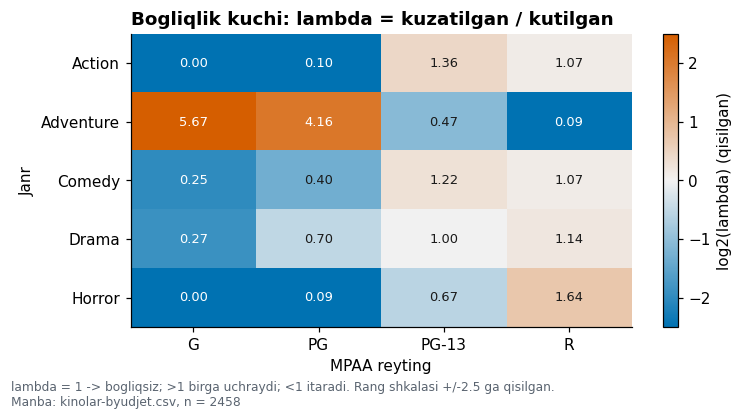

In [21]:
# --- lambda ni vizuallashtirish ---------------------------------------
# DIQQAT: grafik yorliqlarida faqat ASCII harflar.
from matplotlib.colors import LinearSegmentedColormap

# Okabe-Ito asosidagi ikki tomonlama (diverging) shkala:
# koʻk (lambda < 1) — oq (lambda = 1) — qizgʻish (lambda > 1).
cmap_oi = LinearSegmentedColormap.from_list(
    "oi_div", [oiBlue, "#F2F2F2", oiVerm])

# MUHIM: ikkita katakda lambda = 0 (Action×G va Horror×G — birorta ham
# film yoʻq). log2(0) = -inf boʻlgani uchun rang shkalasi butunlay
# buziladi. Shu sababli log2(lambda) ni [-2.5, 2.5] oraligʻiga QISAMIZ
# (clamp). Bu — vizual qaror, uni izohda oshkora aytish shart.
with np.errstate(divide="ignore"):
    M = np.clip(np.log2(lam.values), -2.5, 2.5)

fig, ax = plt.subplots(figsize=(7.0, 3.6))
im = ax.imshow(M, cmap=cmap_oi, vmin=-2.5, vmax=2.5, aspect="auto")

ax.set_xticks(range(len(reytinglar)), reytinglar)
ax.set_yticks(range(len(janrlar)), janrlar)
for i in range(len(janrlar)):
    for j in range(len(reytinglar)):
        # Toʻq fonda oq, ochiq fonda qora matn — kontrast kafolatlanadi.
        rang = "white" if abs(M[i, j]) > 1.6 else "#1A1A1A"
        ax.text(j, i, f"{lam.values[i, j]:.2f}", ha="center", va="center",
                fontsize=8.5, color=rang)

ax.set_title("Bogliqlik kuchi: lambda = kuzatilgan / kutilgan",
             fontweight="bold", loc="left")
ax.set_xlabel("MPAA reyting"); ax.set_ylabel("Janr")
ax.grid(False)
fig.colorbar(im, ax=ax, label="log2(lambda) (qisilgan)")
fig.text(0.01, -0.04, "lambda = 1 -> bogliqsiz; >1 birga uchraydi; <1 itaradi. "
         "Rang shkalasi +/-2.5 ga qisilgan.\nManba: kinolar-byudjet.csv, n = 2458",
         fontsize=8, color="#5A6470")
plt.tight_layout(); plt.show()

### Natija (kutilayotgan)

```
--- Drama va R ---
  P(Drama)        = 0.3779    n = 929
  P(R)            = 0.4528    n = 1113
  P(kesishma)     = 0.1949    n = 479
  P(Drama)P(R)    = 0.1711
  kutilgan son    = 420.66   kuzatilgan = 479
  NISBAT lambda   = 1.1387
  P(R|Drama) = 0.5156   vs   P(R) = 0.4528   (farq 0.0628)

--- Drama va PG13 ---
  P(Drama)        = 0.3779    n = 929
  P(PG13)         = 0.3645    n = 896
  P(kesishma)     = 0.1379    n = 339
  P(Drama)P(PG13) = 0.1378
  kutilgan son    = 338.64   kuzatilgan = 339
  NISBAT lambda   = 1.0011
  P(PG13|Drama) = 0.3649   vs   P(PG13) = 0.3645   (farq 0.0004)

lambda(Drama, R)    = 1.1387   ->  |lambda-1| = 0.1387
lambda(Drama, PG13) = 1.0011   ->  |lambda-1| = 0.0011
bogʻliqlik kuchi 131 barobar farq qiladi

lambda jadvali (janr x reyting):
               G     PG  PG-13      R
Action     0.000  0.103  1.364  1.073
Adventure  5.666  4.164  0.469  0.085
Comedy     0.251  0.399  1.216  1.075
Drama      0.270  0.701  1.001  1.139
Horror     0.000  0.089  0.673  1.635
```

### Talqin — daftaringizga yozing

**T3.1** (Drama, PG-13) juftligida kutilgan son $338{,}64$, kuzatilgan
$339$ — farq bitta filmdan kam. Bu juftlik **bogʻliqsiz** deb aytish
mumkinmi? Javobingizda «bogʻliqsiz» va «bogʻliqsizlikdan sezilarli
chetlanish aniqlanmadi» iboralarining farqini koʻrsating.

**T3.2** $\lambda = 1{,}1387$ ni **soʻz bilan** tushuntiring: «Drama va R
birga … barobar koʻp uchraydi». Bu 14 % ortiqcha — amaliy jihatdan katta
farqmi? Javobingizni kutilgan va kuzatilgan sonlar (420,66 va 479) orqali
asoslang.

**T3.3** 2-topshiriqda $B$ (R) va $C$ (G) **birgalikda boʻlmagan** edi.
Ular uchun $\lambda$ ni hisoblang. Natijani izohlang: birgalikda boʻlmagan
hodisalar bogʻliqsizlik shkalasining qaysi uchida turadi?

**T3.4** $\lambda$ jadvalidagi eng katta va eng kichik qiymatlarni toping.
Ular qaysi juftliklar? Bu natijalar kinoindustriya haqida qanday
**mazmunli** (statistik emas) haqiqatni aytadi?

**T3.5** Butun jadvalda bogʻliqlik topildi. Bu «janr reytingni **keltirib
chiqaradi**» degani emas. Nima uchun emas? Kamida bitta uchinchi omilni
nomlang.

### Qaror

Studiya rahbari: «Drama suratga olsak, R reyting olish ehtimoli
oʻrtachadan yuqori». Bu jumla maʼlumot bilan tasdiqlanadimi? Aynan qaysi
ikki sonni yonma-yon qoʻyib javob berasiz? Bir jumlada yozing.

---
## 4-topshiriq. Shartli ehtimollik ikki yoʻnalishda

**Qiyinlik: 4 (Analitik) · Blum: Tahlil · 15 ball · 15 daqiqa**

### Statistik tushuncha

**Shartli ehtimollik** *(conditional probability)*:

$$\Pr(A \mid B) \;=\; \frac{\Pr(A \cap B)}{\Pr(B)},\qquad \Pr(B) > 0.$$

Maʼnosi: **fazoni toraytirish**. Endi maxraj $n$ emas, $n(B)$.

$\Pr(A \mid B)$ va $\Pr(B \mid A)$ **umuman boshqa sonlar**, chunki
maxrajlar boshqa. Ularni chalkashtirish — sud amaliyotida **prokuror
xatosi** *(prosecutor's fallacy)* deb ataladi va real hukmlarga sabab
boʻlgan.

**Koʻpaytirish qoidasi** *(multiplication rule)*:
$\Pr(A \cap B) = \Pr(B)\Pr(A \mid B) = \Pr(A)\Pr(B \mid A)$.

### Maʼlumot

$H = \{\text{Horror}\}$, $V = \{\text{Adventure}\}$, $B = \{\text{R}\}$.

In [22]:
# --- Shartli ehtimollikni IKKI usulda hisoblash -----------------------
H = kino_t["janr"] == "Horror"
V = kino_t["janr"] == "Adventure"

tarif      = (H & B).mean() / H.mean()   # 1-usul: taʼrif boʻyicha
toraytirib = B[H].mean()                 # 2-usul: fazoni toraytirib

print("P(R|Horror): taʼrif = {:.4f} | toraytirib = {:.4f} | mos = {}".format(
    tarif, toraytirib, np.isclose(tarif, toraytirib)))
print("  maxraj: n(Horror) = {}  (n = {} emas!)".format(int(H.sum()), n))

P(R|Horror): taʼrif = 0.7404 | toraytirib = 0.7404 | mos = True
  maxraj: n(Horror) = 208  (n = 2458 emas!)


In [23]:
# --- IKKI YOʻNALISH: bir xil kesishma, boshqa maxraj -------------------
PRH = B[H].mean()      # P(R | Horror)   maxraj n(Horror) = 208
PHR = H[B].mean()      # P(Horror | R)   maxraj n(R)      = 1113

print("P(R | Horror) = {:3d}/{:4d} = {:.4f}".format(
    int((H & B).sum()), int(H.sum()), PRH))
print("P(Horror | R) = {:3d}/{:4d} = {:.4f}".format(
    int((H & B).sum()), int(B.sum()), PHR))
print("SURAT bir xil ({}), MAXRAJ boshqa -> nisbat {:.2f} barobar".format(
    int((H & B).sum()), PRH / PHR))

P(R | Horror) = 154/ 208 = 0.7404
P(Horror | R) = 154/1113 = 0.1384
SURAT bir xil (154), MAXRAJ boshqa -> nisbat 5.35 barobar


In [24]:
# --- Shartlash ehtimollikni qanchalik oʻzgartiradi? -------------------
print("P(R)              = {:.4f}   (shartsiz)".format(B.mean()))
print("P(R | Horror)     = {:.4f}   ({:.1f} barobar yuqori)".format(
    B[H].mean(), B[H].mean() / B.mean()))
print("P(R | Adventure)  = {:.4f}   ({:.1f} barobar past)".format(
    B[V].mean(), B.mean() / B[V].mean()))
print("Horror va Adventure orasidagi farq: {:.1f} barobar".format(
    B[H].mean() / B[V].mean()))

P(R)              = 0.4528   (shartsiz)
P(R | Horror)     = 0.7404   (1.6 barobar yuqori)
P(R | Adventure)  = 0.0386   (11.7 barobar past)
Horror va Adventure orasidagi farq: 19.2 barobar


In [25]:
# --- Koʻpaytirish qoidasini tekshirish --------------------------------
# P(A∩B) ni UCH xil yoʻl bilan olamiz. Uchalasi teng chiqishi shart.
y1 = (A & B).mean()               # bevosita sanash
y2 = A.mean() * B[A].mean()       # P(A)·P(B|A)
y3 = B.mean() * A[B].mean()       # P(B)·P(A|B)

print("bevosita        : {:.6f}".format(y1))
print("P(A)·P(B|A)     : {:.4f} × {:.4f} = {:.6f}".format(
    A.mean(), B[A].mean(), y2))
print("P(B)·P(A|B)     : {:.4f} × {:.4f} = {:.6f}".format(
    B.mean(), A[B].mean(), y3))
print("uchalasi teng   :", np.isclose(y1, y2) and np.isclose(y1, y3))

bevosita        : 0.194874
P(A)·P(B|A)     : 0.3779 × 0.5156 = 0.194874
P(B)·P(A|B)     : 0.4528 × 0.4304 = 0.194874
uchalasi teng   : True


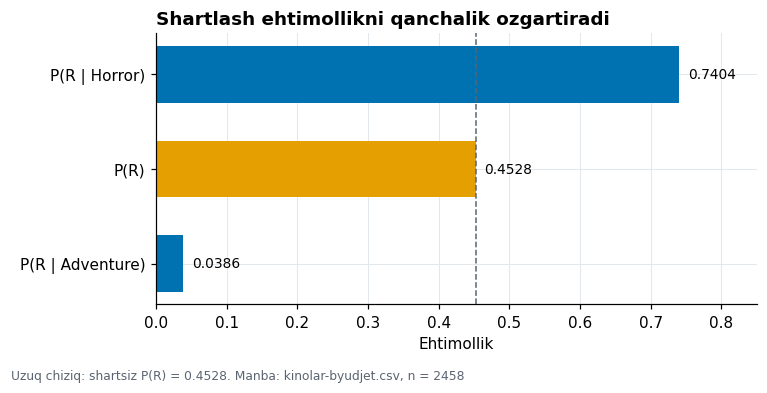

In [26]:
# --- Shartlash taʼsirini koʻrsatuvchi grafik --------------------------
nomlar  = ["P(R | Adventure)", "P(R)", "P(R | Horror)"]
qiymat  = [B[V].mean(), B.mean(), B[H].mean()]
ranglar = [oiBlue, oiOrange, oiBlue]

fig, ax = plt.subplots(figsize=(7.0, 3.4))
ax.barh(nomlar, qiymat, color=ranglar, height=0.6)
ax.axvline(B.mean(), linestyle="--", color="#5A6470", linewidth=1)
for i, v in enumerate(qiymat):
    ax.text(v + 0.012, i, f"{v:.4f}", va="center", fontsize=9)

ax.set_xlim(0, 0.85)
ax.set_xlabel("Ehtimollik")
ax.set_title("Shartlash ehtimollikni qanchalik ozgartiradi",
             fontweight="bold", loc="left")
fig.text(0.01, -0.03, "Uzuq chiziq: shartsiz P(R) = 0.4528. "
         "Manba: kinolar-byudjet.csv, n = 2458",
         fontsize=8, color="#5A6470")
plt.tight_layout(); plt.show()

### Natija (kutilayotgan)

```
P(R|Horror): taʼrif = 0.7404 | toraytirib = 0.7404 | mos = True
  maxraj: n(Horror) = 208  (n = 2458 emas!)

P(R | Horror) = 154/ 208 = 0.7404
P(Horror | R) = 154/1113 = 0.1384
SURAT bir xil (154), MAXRAJ boshqa -> nisbat 5.35 barobar

P(R)              = 0.4528
P(R | Horror)     = 0.7404   (1.6 barobar yuqori)
P(R | Adventure)  = 0.0386   (11.7 barobar past)
Horror va Adventure orasidagi farq: 19.2 barobar

bevosita     : 0.194874
P(A)·P(B|A)  : 0.3779 × 0.5156 = 0.194874
P(B)·P(A|B)  : 0.4528 × 0.4304 = 0.194874
uchalasi teng: True
```

### Talqin — daftaringizga yozing

**T4.1** $\Pr(R \mid \text{Horror}) = 0{,}7404$ va
$\Pr(\text{Horror} \mid R) = 0{,}1384$. Surat ikkalasida ham $154$. Farq
**faqat** maxrajdanmi? Har bir maxraj qanday fazoni bildiradi? Ikki jumla
bilan yozing.

**T4.2** Quyidagi jumlani toʻgʻrilang: «R reytingli filmlarning 74 % i
qoʻrqinchli filmlar». Xato qayerda? Toʻgʻri jumlani yozing va toʻgʻri
sonni koʻrsating.

**T4.3** **Prokuror xatosi.** Sud ekspertizasi: «Agar ayblanuvchi aybsiz
boʻlsa, dalilning bunday mos kelishi ehtimoli $1/10\,000$». Prokuror:
«Demak, ayblanuvchining aybsizlik ehtimoli $1/10\,000$». Bu ikki jumla
qanday shartli ehtimolliklarni bildiradi? Nima uchun ikkinchisi
birinchisidan **kelib chiqmaydi**? Yuqoridagi Horror misolini analogiya
sifatida ishlating.

**T4.4** $\Pr(R \mid \text{Adventure}) = 0{,}0386$ — bu $\Pr(R)$ dan
qariyb 12 barobar past. Shartlash ehtimollikni **oshirishi ham,
kamaytirishi ham** mumkin. Qaysi holatda shartlash ehtimollikni umuman
oʻzgartirmaydi? (Javobingiz 3-topshiriq bilan bogʻlansin.)

### Qaror

Onlayn kinoteatr «qoʻrqinchli film → yosh cheklovi ogohlantirishi»
avtomatik qoidasini joriy qilmoqchi. Ushbu qoida qaysi shartli
ehtimollikka tayanadi? Qoida qanchalik toʻgʻri ishlaydi va necha foiz
holatda ortiqcha ogohlantirish beradi? Sonlar bilan javob bering.

---
## 5-topshiriq. Monte-Karlo va katta sonlar qonuni

**Qiyinlik: 5 (Ilgʻor) · Blum: Baholash · 25 ball · 25 daqiqa**

### Statistik tushuncha

**Monte-Karlo simulyatsiyasi** *(Monte Carlo simulation)* — tajribani
kompyuterda koʻp marta takrorlab, hodisaning **nisbiy chastotasi** bilan
ehtimollikni baholash usuli.

**Katta sonlar qonuni** *(law of large numbers)*: $n \to \infty$ da nisbiy
chastota $\hat{p}_n$ ehtimollik $p$ ga **yaqinlashadi**.

> **Diqqat.** Qonun *yaqinlashishni* kafolatlaydi, **monoton
> yaxshilanishni emas**. $n$ ni oshirganda xato *ayrim qadamlarda oshishi*
> mumkin — bugun buni oʻz koʻzingiz bilan koʻrasiz.

Baholash xatosi taxminan $\sqrt{p(1-p)/n}$ ga proporsional: aniqlikni $10$
barobar oshirish uchun $n$ ni $100$ barobar oshirish kerak.

### Maʼlumot — bu yerda maʼlumotni **oʻzimiz yaratamiz**

Bu topshiriqda faylni oʻqimaymiz: tasodifiy sonlarni generatsiya qilamiz.
Shu sababli **urugʻ (seed)** ni belgilash majburiy — aks holda natija har
safar oʻzgaradi va ish takrorlanmaydigan boʻlib qoladi.

In [27]:
# --- 1-qadam: TILGA XOS generator ------------------------------------
# np.random.default_rng(2026) — numpy ning zamonaviy generatori (PCG64).
# Natija Pythonda har safar bir xil chiqadi.
rng = np.random.default_rng(2026)
print("Python, default_rng(2026):", rng.integers(1, 7, 20))

rng = np.random.default_rng(2026)
print("Python, yana        (2026):", rng.integers(1, 7, 20))

# MUHIM PEDAGOGIK NUQTA:
# R daftarida set.seed(2026) BOSHQA sonlar beradi (Mersenne-Twister).
# Bu XATO EMAS. Takrorlanuvchanlik =
#   bir xil urugʻ + bir xil generator + bir xil dastur versiyasi.
# Shu sababli quyida R va Python AYNAN bir xil son berishi uchun
# umumiy generatorni oʻzimiz yozamiz.

Python, default_rng(2026): [6 2 1 4 3 3 1 3 4 3 5 5 5 6 5 2 6 4 1 2]
Python, yana        (2026): [6 2 1 4 3 3 1 3 4 3 5 5 5 6 5 2 6 4 1 2]


In [28]:
# --- 2-qadam: UMUMIY generator (MINSTD / Lehmer) ----------------------
# x[k+1] = (48271 * x[k]) mod 2147483647,   u[k] = x[k] / 2147483647
#
# Nima uchun aynan shu sonlar? Eng katta oraliq koʻpaytma
#   48271 × 2147483646 = 103 661 183 076 066  <  2^53 = 9 007 199 254 740 992
# yaʼni u R ning double turida VA Pythonning butun sonida AYNAN bir xil
# hisoblanadi. Natijada ikkala tilda bir xil sonlar oqimi chiqadi.
class Minstd:
    """R va Pythonda AYNAN bir xil oqim beradigan generator."""
    M = 2147483647
    A = 48271

    def __init__(self, urugh):
        self.x = urugh % self.M
        if self.x == 0:
            self.x = 1

    def uniform(self, k):
        """Keyingi k ta u ~ (0,1) sonini qaytaradi."""
        out = np.empty(k)
        x = self.x                      # mahalliy oʻzgaruvchi — tezroq
        for i in range(k):
            x = (self.A * x) % self.M
            out[i] = x / self.M
        self.x = x                      # holatni saqlaymiz
        return out


# Nazorat qiymatlari — R daftaridagi sonlar bilan SOLISHTIRING.
g = Minstd(2026)
for i, v in enumerate(g.uniform(5), 1):
    print(f"u[{i}] = {v:.10f}")

u[1] = 0.0455402984
u[2] = 0.2757419647
u[3] = 0.3403783731
u[4] = 0.4044473546
u[5] = 0.0782521903


In [29]:
# --- 3-qadam: 100 000 marta zar tashlash ------------------------------
N = 100_000
g = Minstd(2026)                  # generatorni BOSHIDAN ishga tushiramiz
u = g.uniform(N)

# np.floor(u*6)+1 — [0,1) oraligʻini 6 ta teng boʻlakka boʻlib, 1..6 ga
# akslantiradi. Har bir yuz teng ehtimolli.
zar = np.floor(u * 6).astype(int) + 1
print("dastlabki 10 tashlash:", zar[:10])

# Chastota jadvali — barcha yuzlar taxminan teng chiqishi kerak.
son = pd.Series(zar).value_counts().sort_index()
print("yuz  :", " ".join(f"{v:>7d}" for v in son.index))
print("son  :", " ".join(f"{v:>7d}" for v in son.values))
print("ulush:", " ".join(f"{v:>7.5f}" for v in son.values / N))

dastlabki 10 tashlash: [1 2 3 3 1 2 3 3 4 3]
yuz  :       1       2       3       4       5       6
son  :   16574   16762   16702   16573   16739   16650
ulush: 0.16574 0.16762 0.16702 0.16573 0.16739 0.16650


In [30]:
# --- 4-qadam: YIGʻILUVCHI baho ----------------------------------------
# np.cumsum(zar == 6) — birinchi k tashlashdagi oltiliklar soni.
# Uni k ga boʻlsak, HAR BIR k uchun baho hosil boʻladi.
kum     = np.cumsum(zar == 6)
baho    = kum / np.arange(1, N + 1)
nazariy = 1 / 6

nlar = np.array([10, 100, 1_000, 10_000, 100_000])
yaqin_jadval = pd.DataFrame({
    "n":    nlar,
    "baho": baho[nlar - 1],                    # indeks 0 dan boshlanadi!
    "xato": np.abs(baho[nlar - 1] - nazariy),
})
print(yaqin_jadval.to_string(index=False,
                             float_format=lambda v: f"{v:.5f}"))
print(f"nazariy 1/6 = {nazariy:.5f}")

     n    baho    xato
    10 0.00000 0.16667
   100 0.08000 0.08667
  1000 0.16700 0.00033
 10000 0.16580 0.00087
100000 0.16650 0.00017
nazariy 1/6 = 0.16667


In [31]:
# --- 5-qadam: XATO MONOTON KAMAYADIMI? --------------------------------
# np.diff() — ketma-ket ayirmalar. Manfiy qiymat: xato kamaydi.
xato    = yaqin_jadval["xato"].to_numpy()
kamaydi = np.diff(xato) < 0
for i, ok in enumerate(kamaydi):
    print("n: {:6d} -> {:6d}   xato {:.5f} -> {:.5f}   {}".format(
        nlar[i], nlar[i + 1], xato[i], xato[i + 1],
        "kamaydi" if ok else "OSHDI  <-- diqqat"))

print("\nXato barcha qadamlarda kamaydimi?", bool(kamaydi.all()))

n:     10 ->    100   xato 0.16667 -> 0.08667   kamaydi
n:    100 ->   1000   xato 0.08667 -> 0.00033   kamaydi
n:   1000 ->  10000   xato 0.00033 -> 0.00087   OSHDI  <-- diqqat
n:  10000 -> 100000   xato 0.00087 -> 0.00017   kamaydi

Xato barcha qadamlarda kamaydimi? False


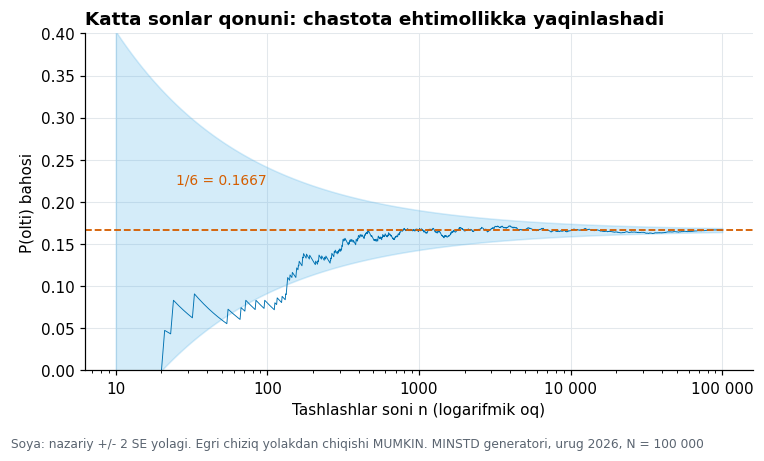

In [32]:
# --- 6-qadam: yaqinlashish grafigi ------------------------------------
# Logarifmik x oʻqi: n = 10 dan 100 000 gacha oraliq juda keng.
indeks = np.unique(np.round(np.exp(
    np.linspace(np.log(10), np.log(N), 3000))).astype(int))

p0    = nazariy
yolak = 2 * np.sqrt(p0 * (1 - p0) / indeks)

fig, ax = plt.subplots(figsize=(7.0, 4.0))
ax.fill_between(indeks, p0 - yolak, p0 + yolak, color=oiSky, alpha=0.25)
ax.plot(indeks, baho[indeks - 1], color=oiBlue, linewidth=0.6)
ax.axhline(p0, color=oiVerm, linewidth=1.2, linestyle="--")
ax.text(25, p0 + 0.055, "1/6 = 0.1667", color=oiVerm, fontsize=9)

ax.set_xscale("log")
ax.set_xticks([10, 100, 1000, 10000, 100000],
              ["10", "100", "1000", "10 000", "100 000"])
ax.set_ylim(0, 0.4)
ax.set_xlabel("Tashlashlar soni n (logarifmik oq)")
ax.set_ylabel("P(olti) bahosi")
ax.set_title("Katta sonlar qonuni: chastota ehtimollikka yaqinlashadi",
             fontweight="bold", loc="left")
fig.text(0.01, -0.03, "Soya: nazariy +/- 2 SE yolagi. Egri chiziq yolakdan "
         "chiqishi MUMKIN. MINSTD generatori, urug 2026, N = 100 000",
         fontsize=8, color="#5A6470")
plt.tight_layout(); plt.show()

In [33]:
# --- 7-qadam: ikki zar yigʻindisi = 7 ---------------------------------
# Generatorni yangidan ishga tushiramiz va 2N ta son olamiz:
# juft indekslar — birinchi zar, toq indekslar — ikkinchi zar.
# (R da seq(1, 2N, 2) va seq(2, 2N, 2) — AYNAN shu tartib.)
g2 = Minstd(2026)
u2 = g2.uniform(2 * N)
z1 = np.floor(u2[0::2] * 6).astype(int) + 1
z2 = np.floor(u2[1::2] * 6).astype(int) + 1
yigindi = z1 + z2

print("nazariy 6/36     = {:.5f}".format(6 / 36))
print("simulyatsiya     = {:.5f}".format((yigindi == 7).mean()))
print("|xato|           = {:.5f}".format(abs((yigindi == 7).mean() - 6 / 36)))

# Butun taqsimotni solishtiramiz: nazariy P(yigindi = s) = (6-|7-s|)/36
s = np.arange(2, 13)
solishtirish = pd.DataFrame({
    "yigindi": s,
    "sim":     [(yigindi == v).mean() for v in s],
    "nazariy": (6 - np.abs(7 - s)) / 36,
})
print(solishtirish.to_string(index=False,
                             float_format=lambda v: f"{v:.5f}"))

nazariy 6/36     = 0.16667
simulyatsiya     = 0.16616
|xato|           = 0.00051
 yigindi     sim  nazariy
       2 0.02785  0.02778
       3 0.05596  0.05556
       4 0.08401  0.08333
       5 0.11217  0.11111
       6 0.13666  0.13889
       7 0.16616  0.16667
       8 0.13851  0.13889
       9 0.11168  0.11111
      10 0.08300  0.08333
      11 0.05608  0.05556
      12 0.02792  0.02778


### Natija (kutilayotgan)

```
u[1] = 0.0455402984      u[2] = 0.2757419647      u[3] = 0.3403783731
u[4] = 0.4044473546      u[5] = 0.0782521903
dastlabki 10 tashlash: [1 2 3 3 1 2 3 3 4 3]

      n     baho     xato
     10  0.00000  0.16667
    100  0.08000  0.08667
   1000  0.16700  0.00033      <- eng aniq baho
  10000  0.16580  0.00087      <- XATO OSHDI
 100000  0.16650  0.00017
nazariy 1/6 = 0.16667

Xato barcha qadamlarda kamaydimi? False

nazariy 6/36 = 0.16667
simulyatsiya = 0.16616
```

**Bu sonlar R daftaridagi sonlar bilan AYNAN bir xil.** Agar farq
koʻrsangiz — generator kodida xatolik bor.

### Talqin — daftaringizga yozing

**T5.1** $n = 1000$ da xato $0{,}00033$, $n = 10\,000$ da $0{,}00087$ —
**oʻn barobar koʻp maʼlumot bilan baho yomonlashdi**. Katta sonlar qonuni
buzildimi? Javobingizda «yaqinlashish» va «monoton kamayish»
tushunchalarini aniq ajrating.

**T5.2** $n = 10$ da baho $0$ chiqdi. Bu «olti tushishi mumkin emas»
degani emas. $n = 10$ da hech qanday olti tushmasligining nazariy
ehtimolini hisoblang: $(5/6)^{10}$. Natija sizni hayron qoldiradimi?

**T5.3** Grafikdagi soyali yoʻlak $\pm 2\sqrt{p(1-p)/n}$. Egri chiziq
yoʻlakdan chiqqan joylarni toping. Bu «xato» belgisimi? Taxminan necha
foiz vaqtda chiqishi **kutiladi**?

**T5.4** Baho aniqligini $10$ barobar oshirish uchun $n$ ni necha barobar
oshirish kerak? Bu qoidani hisob-kitob bilan koʻrsating va
simulyatsiyaning **amaliy chegarasi** haqida xulosa chiqaring.

**T5.5 (muhim).** R va Python daftarlarida `set.seed(2026)` va
`default_rng(2026)` **turli** sonlar berdi; MINSTD esa **bir xil** sonlar
berdi. «Takrorlanuvchi tadqiqot» uchun hisobotda nimalarni yozish shart?
Kamida toʻrtta bandni sanang.

### Qaror

Sugʻurta kompaniyasi kamdan-kam uchraydigan hodisa ($p \approx 0{,}001$)
ehtimolini simulyatsiya bilan baholamoqchi va $\pm 10\,\%$ nisbiy aniqlik
talab qilmoqda. $\sqrt{p(1-p)/n}$ formulasidan foydalanib kerakli $n$ ni
taxminlang. Simulyatsiya bu masala uchun toʻgʻri vositami, yoki analitik
yechim izlash kerakmi? Asoslang.

---
## 6-topshiriq. Tugʻilgan kun masalasi

**Qiyinlik: 5 (Ilgʻor) · Blum: Baholash · 20 ball · 20 daqiqa**

### Statistik tushuncha

**Masala.** Xonada $k$ kishi bor. Kamida ikkitasining tugʻilgan kuni mos
kelishi ehtimoli qancha?

**Toʻgʻridan-toʻgʻri hisoblash juda ogʻir**: «kamida ikkita» degani
$2, 3, 4, \dots$ kishilik barcha mos kelishlarni sanashni talab qiladi.
**Toʻldiruvchiga oʻtish** masalani bir qatorga tushiradi:

$$\Pr(\text{kamida bitta mos}) \;=\; 1 - \Pr(\text{barchasi turlicha})
\;=\; 1 - \prod_{i=0}^{k-1}\frac{365-i}{365}.$$

**Shartlar** *(assumptions)*: 365 kun, hammasi teng ehtimolli, kabisa yili
yoʻq, tugʻilgan kunlar bogʻliqsiz (egizaklar yoʻq), mavsumiylik yoʻq.
Bularning hech biri toʻliq toʻgʻri emas — ammo aniq javob haqiqiy javobga
juda yaqin.

In [34]:
# --- Aniq formula ------------------------------------------------------
# np.prod() — koʻpaytma: (365-0)/365 * (365-1)/365 * ... * (365-(k-1))/365
def tugilgan_aniq(k):
    if k > 365:
        return 1.0
    return 1 - np.prod((365 - np.arange(k)) / 365)


klar = [5, 10, 20, 22, 23, 30, 40, 50, 57, 70]
aniq = np.array([tugilgan_aniq(k) for k in klar])
print(pd.DataFrame({"k": klar, "aniq": aniq.round(4)}).to_string(index=False))

 k   aniq
 5 0.0271
10 0.1169
20 0.4114
22 0.4757
23 0.5073
30 0.7063
40 0.8912
50 0.9704
57 0.9901
70 0.9992


In [35]:
# --- Simulyatsiya ------------------------------------------------------
# Har bir k uchun TAKROR ta «xona» yaratamiz. Bitta xonada k ta tugʻilgan
# kun; noyob qiymatlar soni k dan kichik boʻlsa — mos kelish bor.
TAKROR = 3000
gb = Minstd(2026)          # bitta generator — ketma-ket ishlatiladi

sim = np.empty(len(klar))
for i, k in enumerate(klar):
    ub = gb.uniform(TAKROR * k)
    # .reshape(TAKROR, k) — sonlarni QATOR boʻyicha toʻldiradi (C tartib).
    # Bu R dagi matrix(..., byrow = TRUE) bilan AYNAN bir xil tartib.
    kunlar = (np.floor(ub * 365).astype(int) + 1).reshape(TAKROR, k)
    mos = np.array([len(np.unique(qator)) < k for qator in kunlar])
    sim[i] = mos.mean()

# DIQQAT: farq/SE nisbati YAXLITLANMAGAN qiymatlardan hisoblanadi.
# Avval yaxlitlab, keyin boʻlish boshqa javob beradi (masalan k = 70 da
# 0.0005/0.0005 = 1.00, aslida esa 0.93). Bu — koʻp uchraydigan xato.
farq_xom = np.abs(sim - aniq)
SE_xom   = np.sqrt(aniq * (1 - aniq) / TAKROR)

natija = pd.DataFrame({
    "k":       klar,
    "sim":     sim.round(4),
    "aniq":    aniq.round(4),
    "farq":    farq_xom.round(4),
    "SE":      SE_xom.round(4),
    "farq_SE": (farq_xom / SE_xom).round(2),
})
print(natija.to_string(index=False))

 k    sim   aniq   farq     SE  farq_SE
 5 0.0243 0.0271 0.0028 0.0030     0.94
10 0.1203 0.1169 0.0034 0.0059     0.58
20 0.3937 0.4114 0.0178 0.0090     1.98
22 0.4633 0.4757 0.0124 0.0091     1.36
23 0.5127 0.5073 0.0054 0.0091     0.59
30 0.7223 0.7063 0.0160 0.0083     1.93
40 0.8850 0.8912 0.0062 0.0057     1.10
50 0.9730 0.9704 0.0026 0.0031     0.85
57 0.9880 0.9901 0.0021 0.0018     1.18
70 0.9987 0.9992 0.0005 0.0005     0.93


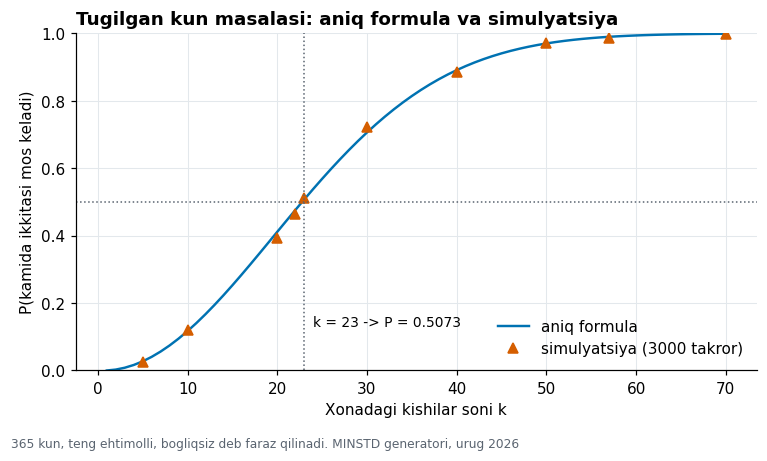

In [36]:
# --- Grafik: simulyatsiya vs aniq formula ------------------------------
kk = np.arange(1, 71)
egri = np.array([tugilgan_aniq(k) for k in kk])

fig, ax = plt.subplots(figsize=(7.0, 4.0))
ax.plot(kk, egri, color=oiBlue, linewidth=1.6, label="aniq formula")
ax.plot(klar, sim, "^", color=oiVerm, markersize=7,
        label="simulyatsiya (3000 takror)")
ax.axhline(0.5, linestyle=":", color="#5A6470", linewidth=1)
ax.axvline(23,  linestyle=":", color="#5A6470", linewidth=1)
ax.text(24, 0.13, "k = 23 -> P = 0.5073", fontsize=9)

ax.set_ylim(0, 1)
ax.set_xlabel("Xonadagi kishilar soni k")
ax.set_ylabel("P(kamida ikkitasi mos keladi)")
ax.set_title("Tugilgan kun masalasi: aniq formula va simulyatsiya",
             fontweight="bold", loc="left")
ax.legend(loc="lower right", frameon=False)
fig.text(0.01, -0.03, "365 kun, teng ehtimolli, bogliqsiz deb faraz "
         "qilinadi. MINSTD generatori, urug 2026",
         fontsize=8, color="#5A6470")
plt.tight_layout(); plt.show()

In [37]:
# --- Eng kichik k: P >= 0.5 va P >= 0.99 ------------------------------
hammasi = np.array([tugilgan_aniq(k) for k in range(1, 81)])
k50 = int(np.argmax(hammasi >= 0.50)) + 1     # argmax — birinchi True
k99 = int(np.argmax(hammasi >= 0.99)) + 1

print(f"P >= 0.50 boʻladigan eng kichik k : {k50} (P = {hammasi[k50-1]:.4f})")
print(f"P >= 0.99 boʻladigan eng kichik k : {k99} (P = {hammasi[k99-1]:.4f})")
print(f"k = 22 da P = {tugilgan_aniq(22):.4f}")

P >= 0.50 boʻladigan eng kichik k : 23 (P = 0.5073)
P >= 0.99 boʻladigan eng kichik k : 57 (P = 0.9901)
k = 22 da P = 0.4757


### Natija (kutilayotgan)

```
 k    sim   aniq   farq     SE  farq_SE
 5 0.0243 0.0271 0.0028 0.0030     0.94
10 0.1203 0.1169 0.0034 0.0059     0.58
20 0.3937 0.4114 0.0178 0.0090     1.98
22 0.4633 0.4757 0.0124 0.0091     1.36
23 0.5127 0.5073 0.0054 0.0091     0.59
30 0.7223 0.7063 0.0160 0.0083     1.93
40 0.8850 0.8912 0.0062 0.0057     1.10
50 0.9730 0.9704 0.0026 0.0031     0.85
57 0.9880 0.9901 0.0021 0.0018     1.18
70 0.9987 0.9992 0.0005 0.0005     0.93

P >= 0.50 boʻladigan eng kichik k : 23 (P = 0.5073)
P >= 0.99 boʻladigan eng kichik k : 57 (P = 0.9901)
k = 22 da P = 0.4757
```

### Talqin — daftaringizga yozing

**T6.1** Nima uchun toʻldiruvchiga oʻtish masalani soddalashtirdi?
«Kamida bitta» hodisasini toʻgʻridan-toʻgʻri sanash uchun nechta holatni
koʻrib chiqish kerak edi?

**T6.2** $k = 23$ da $P = 0{,}5073$ — koʻpchilik $180$ atrofidagi javob
kutadi. Intuitsiya qayerda adashadi? **Juftliklar sonini**
$\binom{23}{2} = 253$ hisoblang va shu son orqali tushuntiring.

**T6.3** Jadvaldagi `farq_SE` ustuni — farqning standart xatoga nisbati.
Barcha qiymatlar $2$ dan kichik. Bu nimani anglatadi? Agar bittasi $4$
chiqqanida, qanday xulosa qilardingiz?

**T6.4** Simulyatsiya $k = 20$ da $0{,}3937$, aniq formula $0{,}4114$
berdi. Qaysi biriga ishonasiz va **nima uchun**? (Diqqat: bu yerda aniq
javob mavjud — simulyatsiya nima uchun kerak boʻlishi mumkin?)

**T6.5** Farazlarni buzamiz: haqiqiy tugʻilishlar yil boʻylab teng
taqsimlanmagan (masalan, sentyabrda koʻproq). Bu haqiqiy $P$ ni
oshiradimi yoki kamaytiradimi? Intuitiv asoslang. *(Maslahat: notekislik
mos kelishni osonlashtiradimi yoki qiyinlashtiradimi?)*

### Qaror

Universitet 30 kishilik guruhlarda «tugʻilgan kun mos kelsa, bepul
tushlik» aksiyasini oʻtkazmoqchi. Har bir guruhda toʻlash ehtimoli qancha?
$50$ ta guruhda kutilayotgan toʻlovlar soni qancha? Aksiyani tavsiya
qilasizmi?

---
## 7-topshiriq (ixtiyoriy, +5 bonus ball). Hosildorlik maʼlumotidagi hodisalar

**Qiyinlik: 6 (Tadqiqotga yoʻnaltirilgan) · Blum: Yaratish · uyda**

### Statistik tushuncha

Bir xil apparat — butunlay boshqa soha. Fazo: $135$ ta *mamlakat–yil*
kuzatuvi. Hodisalar: $U$ = «kuzatuv Oʻzbekistonga tegishli»,
$Y$ = «bugʻdoy hosildorligi mintaqa medianasidan yuqori».

In [38]:
# --- Maʼlumot ---------------------------------------------------------
hos = pd.read_csv("data/markaziy-osiyo-hosildorlik.csv", encoding="utf-8")

# --- LOKAL TUZOGʻI (R da) ---------------------------------------------
# R da quyidagi kod AYRIM MUHITLARDA JIMGINA ishlamay qoladi:
#     U <- hos$mamlakat == "Oʻzbekiston"
# chunki kod ichidagi satr va fayldan oʻqilgan satr turlicha
# belgilangan boʻlishi mumkin. Python bu muammodan xoli, ammo ikkala
# daftarda BIR XIL usul qoʻllanadi:
# nomni fayldan OLIB kelamiz — literal yozmaymiz.
mamlakatlar = sorted(hos["mamlakat"].unique())
print(mamlakatlar)

uz = mamlakatlar[0]                  # alifbo tartibida birinchisi
print("tanlangan mamlakat:", uz,
      "| kuzatuvlar:", int((hos["mamlakat"] == uz).sum()))

# Tekshiruv: agar 27 ta chiqmasa, nom mos kelmagan — davom etmang.
assert (hos["mamlakat"] == uz).sum() == 27

['Oʻzbekiston', 'Qirgʻiziston', 'Qozogʻiston', 'Tojikiston', 'Turkmaniston']
tanlangan mamlakat: Oʻzbekiston | kuzatuvlar: 27


In [39]:
# --- Hodisalar va bogʻliqsizlik ---------------------------------------
mediana = hos["bugdoy"].median()      # BUTUN mintaqa boʻyicha
U = hos["mamlakat"] == uz
Y = hos["bugdoy"] > mediana

print(f"mintaqa bugʻdoy medianasi = {mediana:.3f} t/ga")
lam_uz = bogliqsizlik(U, Y, "UZ", "yuqori")   # qaytgan qiymatni saqlaymiz

mintaqa bugʻdoy medianasi = 1.997 t/ga
--- UZ va yuqori ---
  P(UZ)           = 0.2000    n = 27
  P(yuqori)       = 0.4963    n = 67
  P(kesishma)     = 0.1778    n = 24
  P(UZ)P(yuqori)  = 0.0993
  kutilgan son    = 13.40   kuzatilgan = 24
  NISBAT lambda   = 1.7910
  P(yuqori|UZ) = 0.8889   vs   P(yuqori) = 0.4963   (farq 0.3926)


### Natija (kutilayotgan)

```
['Oʻzbekiston', 'Qirgʻiziston', 'Qozogʻiston', 'Tojikiston', 'Turkmaniston']
tanlangan mamlakat: Oʻzbekiston | kuzatuvlar: 27
mintaqa bugʻdoy medianasi = 1.997 t/ga
--- UZ va yuqori ---
  P(UZ)           = 0.2000    n = 27
  P(yuqori)       = 0.4963    n = 67
  P(kesishma)     = 0.1778    n = 24
  P(UZ)P(yuqori)  = 0.0993
  kutilgan son    = 13.40   kuzatilgan = 24
  NISBAT lambda   = 1.7910
  P(yuqori|UZ) = 0.8889   vs   P(yuqori) = 0.4963   (farq 0.3926)
```

### Talqin va qaror

**T7.1** $\Pr(Y \mid U) = 0{,}8889$, $\Pr(Y) = 0{,}4963$. Bu **sababiy**
xulosa emas. Kamida ikkita chalgʻituvchi omilni nomlang va har biri uchun
mexanizmni koʻrsating (masalan: sugʻoriladigan va lalmi dehqonchilik
ulushi).

**T7.2** Mediana **butun mintaqa** boʻyicha olindi. Agar u faqat
Oʻzbekiston maʼlumotidan olinganida, $\Pr(Y \mid U)$ qanday boʻlardi?
Hisoblang va farqni tushuntiring.

**T7.3** Kuzatuv birligi — *mamlakat–yil*. Bir mamlakatning ketma-ket
yillari bir-biriga bogʻliq (hosildorlik yildan yilga oʻsib boradi). Bu
«teng imkoniyatli va bogʻliqsiz kuzatuvlar» farazini buzadimi? Bu
$\lambda$ ni talqin qilishga qanday taʼsir qiladi?

**Qaror.** Ushbu tahlil asosida «Oʻzbekistonda bugʻdoy yetishtirish
samaraliroq» degan xulosa chiqarish mumkinmi? Bir xatboshi bilan
asoslangan javob yozing.

---
## Yakuniy nazorat roʻyxati

In [40]:
# Barcha asosiy natijalarni bitta jadvalda yigʻamiz — topshirishdan oldin
# ularni kutilayotgan qiymatlar bilan solishtiring.
xulosa = pd.DataFrame({
    "koʻrsatkich": ["n = |S|", "P(Drama)", "P(R)", "P(Drama∩R)",
                    "P(Drama∪R)", "lambda(Drama,R)", "lambda(Drama,PG13)",
                    "P(R|Horror)", "P(Horror|R)", "P^(olti), n=100000",
                    "P(kamida 1 mos), k=23"],
    "qiymat": [n, round(A.mean(), 4), round(B.mean(), 4),
               round((A & B).mean(), 4), round((A | B).mean(), 4),
               round(lam1, 4), round(lam2, 4),
               round(B[H].mean(), 4), round(H[B].mean(), 4),
               round(baho[N - 1], 5), round(tugilgan_aniq(23), 4)],
})
print(xulosa.to_string(index=False))

          koʻrsatkich    qiymat
              n = |S| 2458.0000
             P(Drama)    0.3779
                 P(R)    0.4528
           P(Drama∩R)    0.1949
           P(Drama∪R)    0.6359
      lambda(Drama,R)    1.1387
   lambda(Drama,PG13)    1.0011
          P(R|Horror)    0.7404
          P(Horror|R)    0.1384
   P^(olti), n=100000    0.1665
P(kamida 1 mos), k=23    0.5073


**Kutilayotgan qiymatlar:** 2458 · 0.3779 · 0.4528 · 0.1949 · 0.6359 ·
1.1387 · 1.0011 · 0.7404 · 0.1384 · 0.16650 · 0.5073

Bu qiymatlar **R daftaridagi qiymatlar bilan aynan bir xil** boʻlishi
kerak. Farq boʻlsa — kodni emas, avval *fazoni* (`n`) tekshiring.

---

## Refleksiya (topshiriq bilan birga topshiriladi)

Har biriga **3–4 jumla** bilan javob bering.

1. **Sanoq va formula.** Bugun har bir ehtimollikni ikki yoʻl bilan
   oldingiz: sanab va formula bilan. Agar ular mos kelmaganida, qaysi
   biriga ishonardingiz va xatoni qanday qidirgan boʻlardingiz?
2. **Bogʻliqsizlik va birgalikda boʻlmaslik.** Ushbu ikki tushuncha sizga
   dars boshida qanday koʻringan edi va endi qanday? Farqni oʻzingizning
   misolingizda tushuntiring.
3. **Yoʻnalish.** $\Pr(A \mid B)$ va $\Pr(B \mid A)$ ni chalkashtirish
   qanday real zarar keltirishi mumkin (tibbiyot, sud, kredit skoring)?
   Bitta aniq holatni tasvirlang.
4. **Simulyatsiya chegarasi.** Simulyatsiya qachon *foydali*, qachon
   *xavfli* vosita boʻladi? Bugungi tajribangizdan misol keltiring.
5. **Takrorlanuvchanlik.** Nima uchun R va Python bir xil urugʻ bilan
   turli sonlar berdi? Bu haqiqiy tadqiqotda qanday muammo tugʻdiradi va
   qanday hal qilinadi?

---

## Topshirish tartibi va akademik halollik

* **Fayl:** bajarilgan `W02-lab-<familiya>.ipynb`.
* **Kod xatosiz ishlashi shart:** *Restart Kernel and Run All Cells* dan
  soʻng hech bir katak xato bermasligi kerak.
* **Talqin va qaror** har bir topshiriq uchun Markdown katagida yozilgan
  boʻlishi shart. Faqat kod — bajarilmagan ish.
* **Muddat:** laboratoriyadan keyingi 48 soat ichida, Moodle.
* **Grafiklar:** faqat Okabe–Ito ranglari; maʼnoni faqat rang bilan
  bermang; oʻq nomlari, oʻlchov birligi va manba koʻrsatilsin.
* **Sonlar:** matnda oʻnli ajratgich — **vergul** ($0{,}6359$); kod
  natijasida — **nuqta** (`0.6359`). Aralashtirmang.
* **Urugʻ:** har bir simulyatsiya natijasi yonida urugʻ va generator nomi
  yozilishi shart.

**Sunʼiy intellekt.** Ruxsat etiladi: kod xatosini topish, funksiya
hujjatini tushuntirish, matnni tahrirlash. **Mumkin emas:** talqin va
qaror bosqichlarini SIʼ ga yozdirish. Ish oxirida qaysi vosita, qaysi
bosqichda va qanday soʻrov bilan ishlatilgani yoziladi.